In [1]:
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import numpy as np
import anndata as ad
import scvelo as scv
from cellbender.remove_background.downstream import anndata_from_h5
from pathlib import Path

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

In [3]:
scdir = "/home/vmartin/projects/pipeline/cellranger/counts"

# Remove ambient RNA

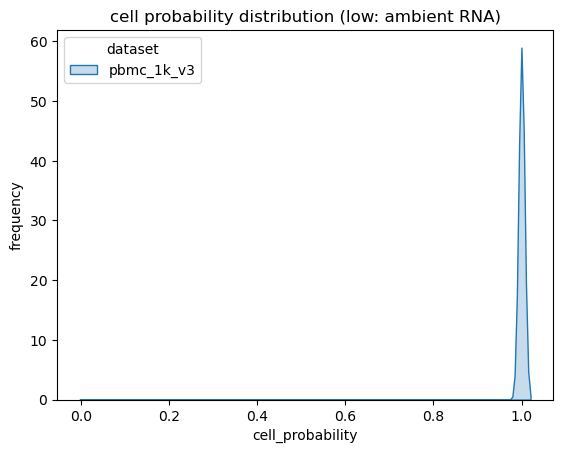

In [ ]:
merged_adata = sc.read(f"{scdir}/merged/pbmc_1k_v3/merged_adata.h5ad")
ax = sns.kdeplot(data = merged_adata.obs[['cell_probability', "batch_names"]], 
                 x = 'cell_probability',fill=True, color='blue', hue = "batch_names")  
plt.title("cell probability distribution (low: ambient RNA)")
plt.xlabel("cell_probability")
plt.ylabel("frequency")
sns.move_legend(ax, "upper left", title='dataset')
plt.show()

In [14]:
adata = merged_adata[merged_adata.obs['cell_probability']  > 0.8]
adata

View of AnnData object with n_obs × n_vars = 1229 × 38606
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'nf', 'umi', 'cell_status', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch_names'
    obsm: 'gene_expression_encoding'

# Filter count matrices

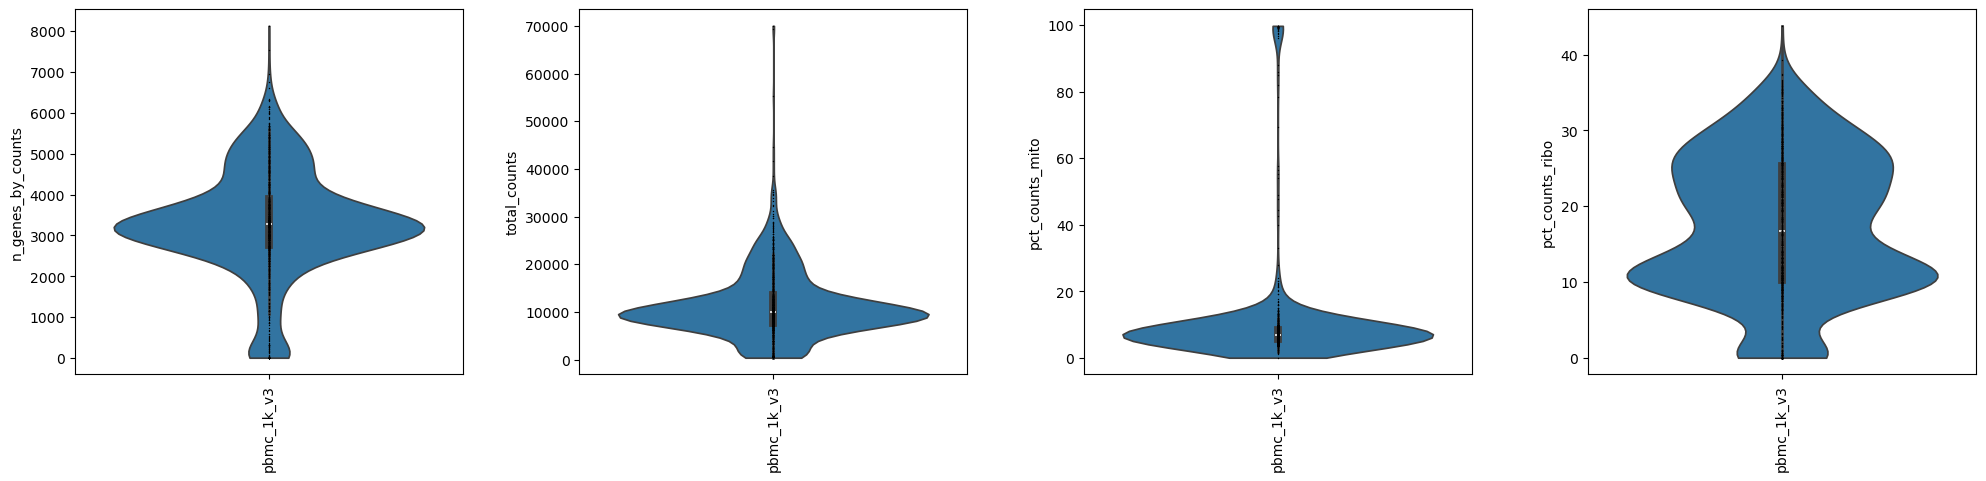

In [15]:
adata.var['mito']=adata.var_names.str.startswith("MT-") 
adata.var['ribo']=adata.var_names.str.startswith(('RPL', 'RPS')) 
sc.pp.calculate_qc_metrics(adata, inplace=True, qc_vars = ['mito', 'ribo'], percent_top=None, log1p = False)
matplotlib.rcParams['figure.figsize'] = [5,5]
sc.pl.violin(adata, groupby="batch_names",
             keys=["n_genes_by_counts", "total_counts",  "pct_counts_mito",'pct_counts_ribo'], 
             multi_panel=True, rotation=90, jitter=False, inner='box')

In [16]:
adata_filtered = adata[(adata.obs["pct_counts_mito"] < 30) & 
                      (adata.obs["total_counts"] < 35000) &
                      (adata.obs["n_genes_by_counts"] < 8000)]
adata_filtered

View of AnnData object with n_obs × n_vars = 1169 × 38606
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'nf', 'umi', 'cell_status', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch_names', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'batch_names_colors'
    obsm: 'gene_expression_encoding'

# Filter on DropletQC metrics

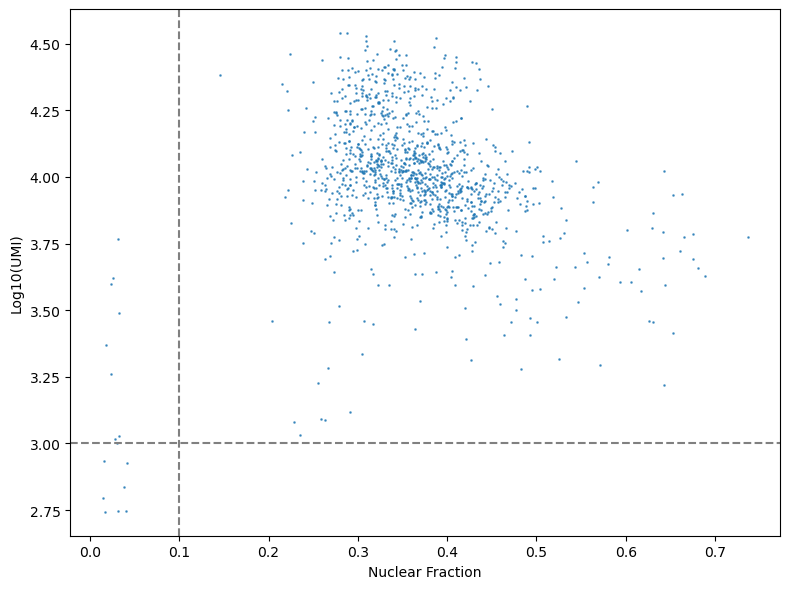

In [20]:
# single-nucleus: 0.6; single-cell: 0.1
nfcutoff = 0.1
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    adata_filtered.obs["nf"],
    np.log10(adata_filtered.obs["umi"]),
    s=0.8, alpha=0.7
)
ax.axvline(nfcutoff, color="gray", ls="--")
ax.axhline(3, color="gray", ls="--")
ax.set_xlabel("Nuclear Fraction")
ax.set_ylabel("Log10(UMI)")
ax.grid(False)
plt.tight_layout()
plt.show()

In [21]:
adata_filtered = adata_filtered[(adata_filtered.obs["nf"] > 0.1)]
adata_filtered

View of AnnData object with n_obs × n_vars = 1153 × 38606
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'nf', 'umi', 'cell_status', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch_names', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'batch_names_colors'
    obsm: 'gene_expression_encoding'

# Filter doublet

In [24]:
sce.pp.scrublet(adata_filtered, batch_key="batch_names")
adata_filtered.obs[['predicted_doublet']].value_counts()
adata_filtered = adata_filtered[~adata_filtered.obs["predicted_doublet"]]

In [25]:
adata_filtered

View of AnnData object with n_obs × n_vars = 1141 × 38606
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'nf', 'umi', 'cell_status', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch_names', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'batch_names_colors', 'scrublet'
    obsm: 'gene_expression_encoding'

# Run scanpy workflow

In [27]:
adata = adata_filtered.copy()
adata = adata[:, ~(
    adata.var_names.str.startswith(
        ("MT-", "RPS", "RPL", "ENSG", "OR")
    )
)].copy()

In [28]:
# 1. Count normalize
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True, exclude_highly_expressed = True)
sc.pp.log1p(adata)
adata.layers["log1p_norm"] = adata.X.copy()

In [ ]:
# 2. Cell cycle scoring
cellcyclepath = "/research/groups/northcgrp/home/common/Rachel/data/genesets/regev_lab_cell_cycle_genes.txt"
cell_cycle_genes = [x.strip() for x in open(cellcyclepath)]
s_genes = [x for x in cell_cycle_genes[:43] if x in adata.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata.var_names]
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

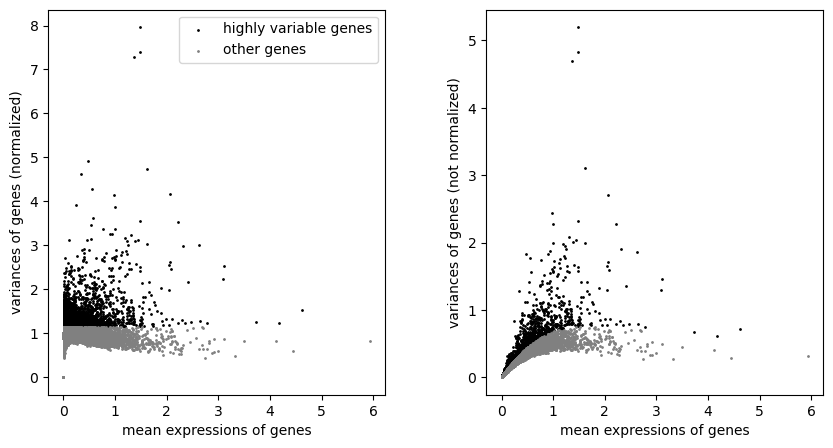

In [30]:
# 3. HVG
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key="batch_names", flavor="seurat_v3")
sc.pl.highly_variable_genes(adata)
adata.raw = adata

In [31]:
# 4. Regress out cell cycle
adata.obs["CC_Difference"] = adata.obs["S_score"] - adata.obs["G2M_score"]
sc.pp.regress_out(adata, keys=["CC_Difference"])
sc.pp.scale(adata, max_value=10)

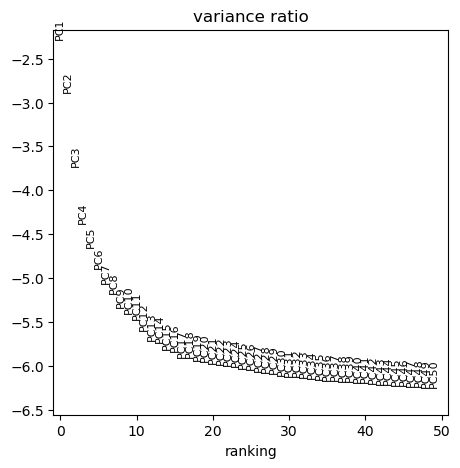

In [32]:
# 5. Dimensionality reduction
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [40]:
# 6. Nearest neighbor graph
sc.pp.neighbors(adata, n_neighbors=40, metric="cosine")
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.3)

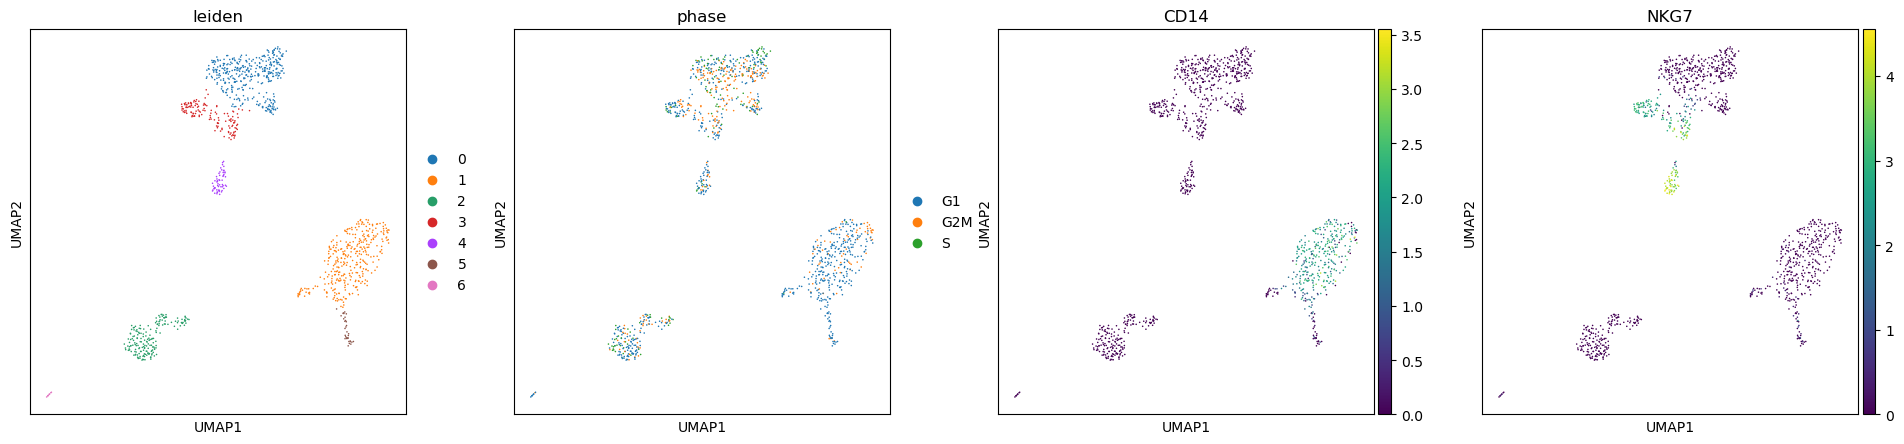

In [41]:
sc.pl.umap(adata, color=["leiden","phase","CD14", "NKG7"], size=5)

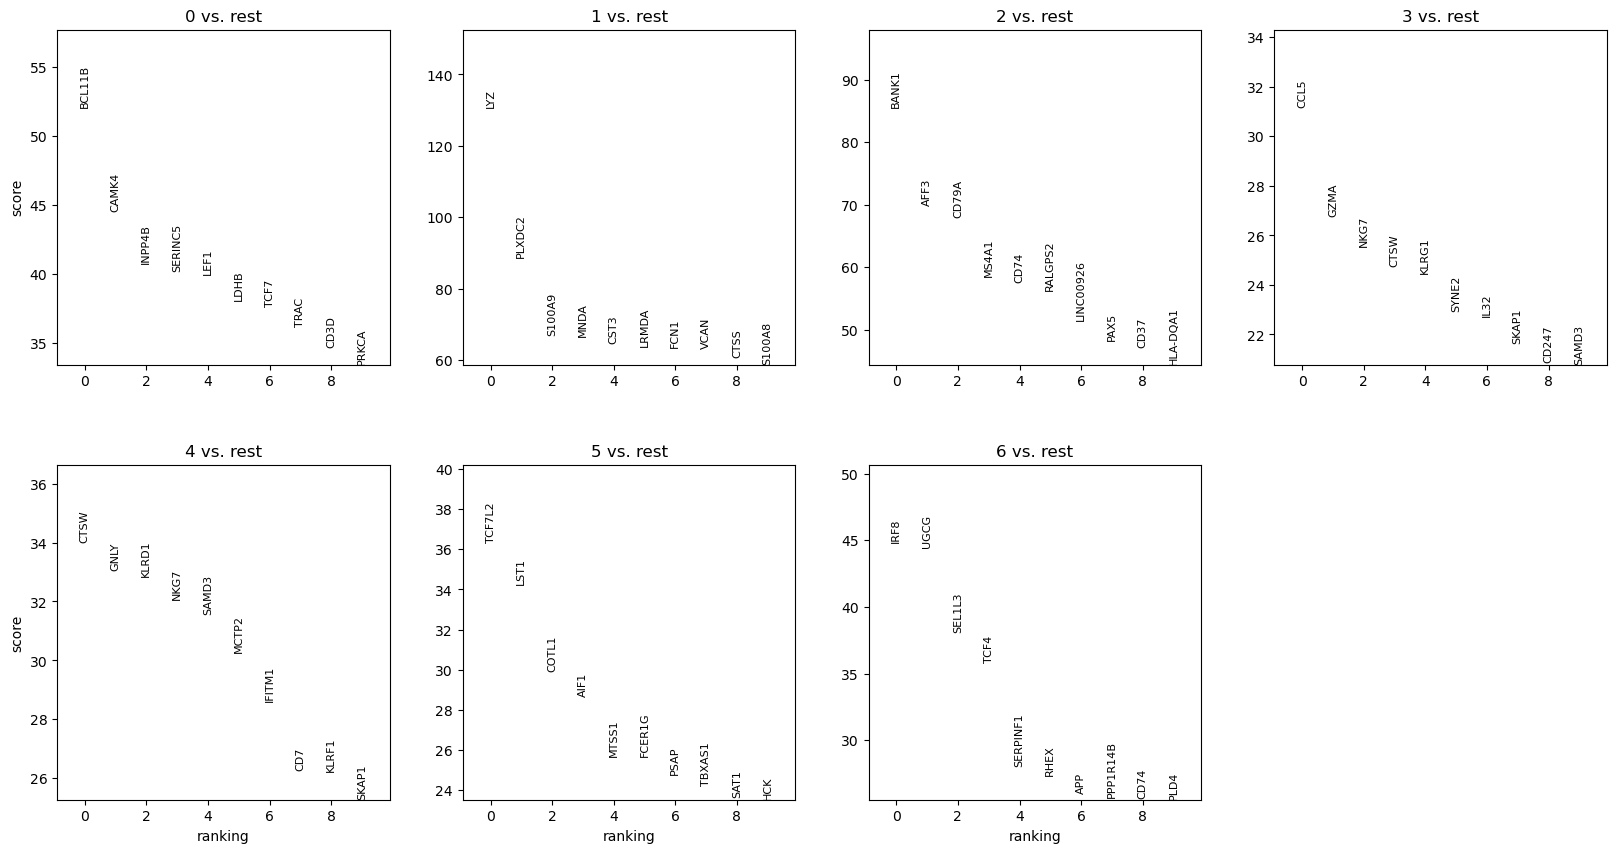

In [42]:
# 7. Find markers
sc.tl.rank_genes_groups(adata, "leiden", mask="var.highly_variable", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [ ]:
sc.get.rank_genes_groups_df(adata, group=None).query("logfoldchanges > 0").groupby("group").head(5)

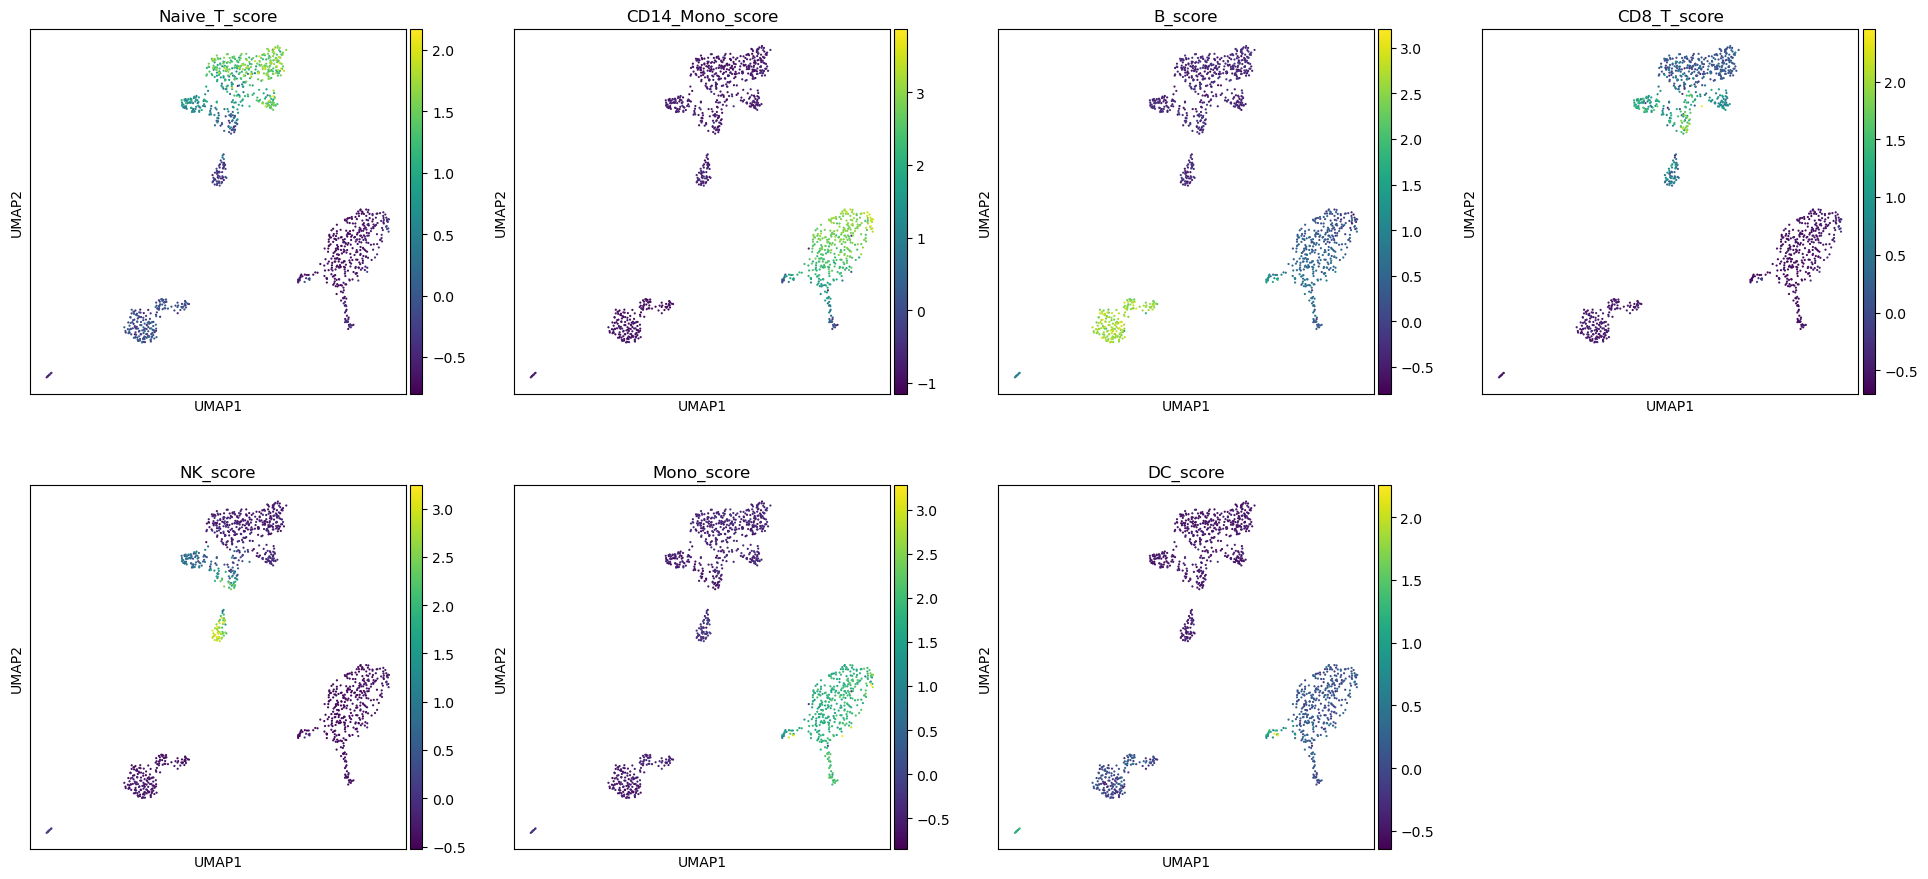

In [50]:
# 8. Cell annotation
marker_genes = {
    "Naive_T": ["BCL11B", "LEF1", "CCR7", "IL7R", "LTB", "MAL"],
    "CD14_Mono": ["LYZ", "S100A8", "S100A9", "FCN1", "CTSD", "MNDA"],
    "B": ["CD79A", "MS4A1", "CD74", "HLA-DRA", "BANK1", "CD37"],
    "CD8_T": ["CD3D", "CD3E", "CD8A", "CD8B", "CCL5", "GZMA"],
    "NK": ["NKG7", "GNLY", "KLRD1", "CTSW", "PRF1", "GZMB"],
    "Mono": ["LYZ", "LST1", "AIF1", "COTL1", "FCER1G", "MS4A7"],
    "DC": ["FCER1A", "CD1C", "CLEC10A", "IRF8", "TCF4", "CST3"],
}

for celltype, genes in marker_genes.items():
    sc.tl.score_genes(
        adata,
        [g for g in genes if g in adata.var_names],
        score_name=f"{celltype}_score"
    )

sc.pl.umap(adata, color=[f"{x}_score" for x in marker_genes], size=10, ncols=4)

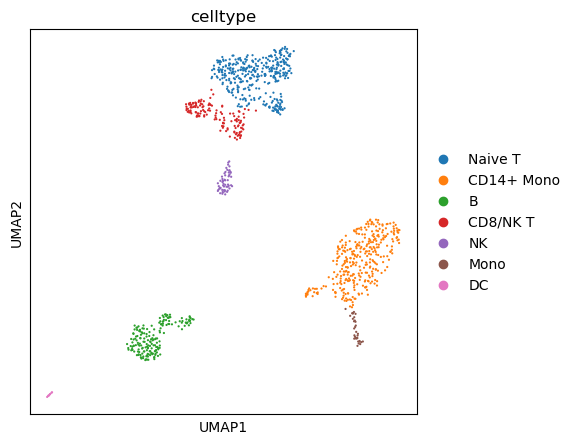

In [49]:
cluster_to_celltype = {
    "0": "Naive T",
    "1": "CD14+ Mono",
    "2": "B",
    "3": "CD8/NK T",
    "4": "NK",
    "5": "Mono",
    "6": "DC"
}

adata.obs["celltype"] = adata.obs["leiden"].map(cluster_to_celltype)
sc.pl.umap(adata, color=["celltype"], size=10)